In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x=np.arange(256)
y=np.sin(2*np.pi*x/30)
y+=max(y)

In [3]:
gen_sin=np.array([[y[j]*127 for j in range(256)] for i in range(256)],dtype=np.uint8)

In [4]:
img=cv2.imread("./test_assets/sandstorm.tif",0)

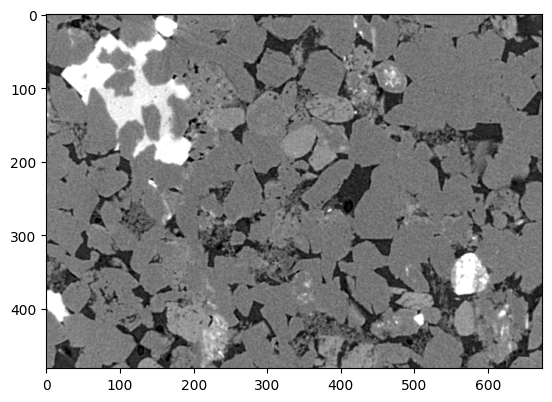

In [5]:
plt.imshow(img, cmap='gray')

In [6]:
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20 * np.log((cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))+1)

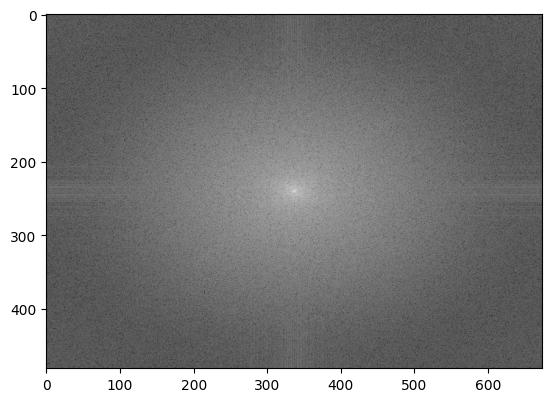

In [7]:
plt.imshow(magnitude_spectrum,cmap='gray')

In [8]:
rows, cols = img.shape
crow, ccol = int(rows / 2), int(cols / 2)

mask = np.ones((rows, cols, 2), np.uint8)
r = 80
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r
mask[mask_area] = 0

In [9]:
# Circular LPF mask, center circle is 1, remaining all zeros
# Only allows low frequency components - smooth regions
#Can smooth out noise but blurs edges.
#
"""
rows, cols = img.shape
crow, ccol = int(rows / 2), int(cols / 2)

mask = np.zeros((rows, cols, 2), np.uint8)
r = 100
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r
mask[mask_area] = 1

# Band Pass Filter - Concentric circle mask, only the points living in concentric circle are ones
rows, cols = img.shape
crow, ccol = int(rows / 2), int(cols / 2)

mask = np.zeros((rows, cols, 2), np.uint8)
r_out = 80
r_in = 10
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = np.logical_and(((x - center[0]) ** 2 + (y - center[1]) ** 2 >= r_in ** 2),
                           ((x - center[0]) ** 2 + (y - center[1]) ** 2 <= r_out ** 2))
mask[mask_area] = 1
"""

'\nrows, cols = img.shape\ncrow, ccol = int(rows / 2), int(cols / 2)\n\nmask = np.zeros((rows, cols, 2), np.uint8)\nr = 100\ncenter = [crow, ccol]\nx, y = np.ogrid[:rows, :cols]\nmask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r\nmask[mask_area] = 1\n\n# Band Pass Filter - Concentric circle mask, only the points living in concentric circle are ones\nrows, cols = img.shape\ncrow, ccol = int(rows / 2), int(cols / 2)\n\nmask = np.zeros((rows, cols, 2), np.uint8)\nr_out = 80\nr_in = 10\ncenter = [crow, ccol]\nx, y = np.ogrid[:rows, :cols]\nmask_area = np.logical_and(((x - center[0]) ** 2 + (y - center[1]) ** 2 >= r_in ** 2),\n                           ((x - center[0]) ** 2 + (y - center[1]) ** 2 <= r_out ** 2))\nmask[mask_area] = 1\n'

In [10]:
# apply mask and inverse DFT: Multiply fourier transformed image (values)
#with the mask values. 
fshift = dft_shift * mask

#Get the magnitude spectrum (only for plotting purposes)
fshift_mask_mag = 20 * np.log(cv2.magnitude(fshift[:, :, 0], fshift[:, :, 1]))

#Inverse shift to shift origin back to top left.
f_ishift = np.fft.ifftshift(fshift)

#Inverse DFT to convert back to image domain from the frequency domain. 
#Will be complex numbers
img_back = cv2.idft(f_ishift)

#Magnitude spectrum of the image domain
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

C:\Users\Asus\AppData\Local\Temp\ipykernel_17860\2129250553.py:6: RuntimeWarning: divide by zero encountered in log
  fshift_mask_mag = 20 * np.log(cv2.magnitude(fshift[:, :, 0], fshift[:, :, 1]))


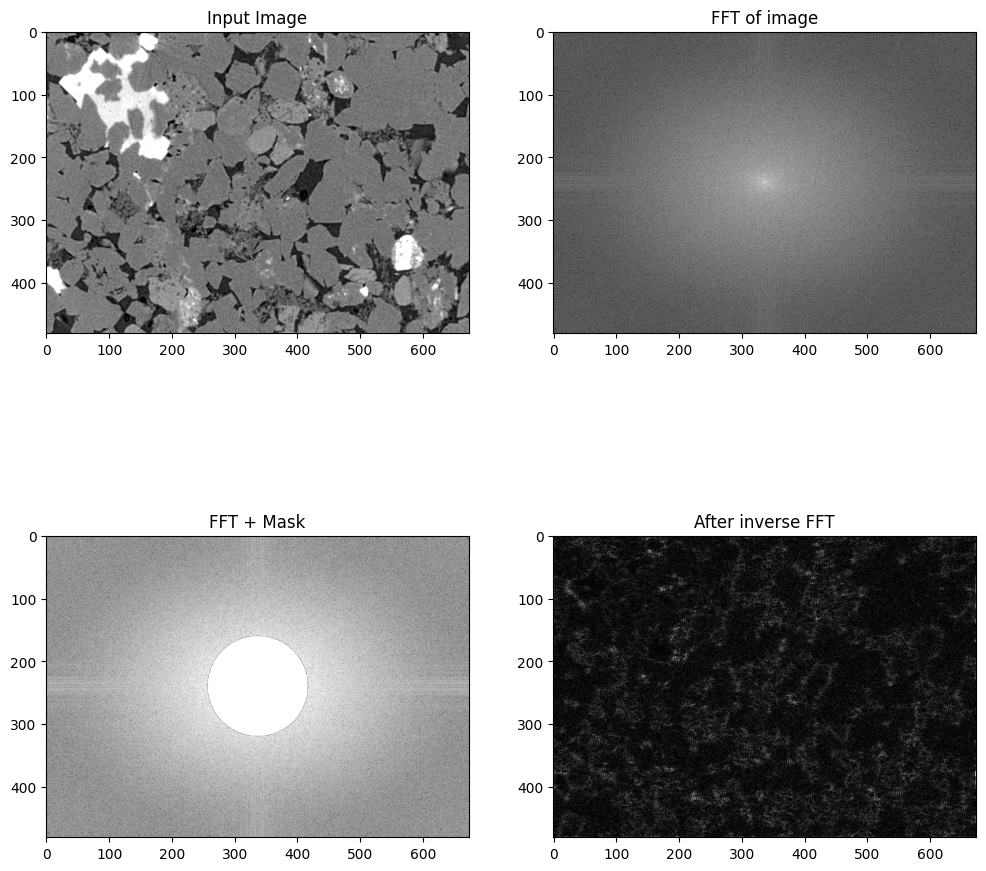

In [11]:
fig = plt.figure(figsize=(12, 12))
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(img, cmap='gray')
ax1.title.set_text('Input Image')
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(magnitude_spectrum, cmap='gray')
ax2.title.set_text('FFT of image')
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(fshift_mask_mag, cmap='gray')
ax3.title.set_text('FFT + Mask')
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(img_back, cmap='gray')
ax4.title.set_text('After inverse FFT')
plt.show()

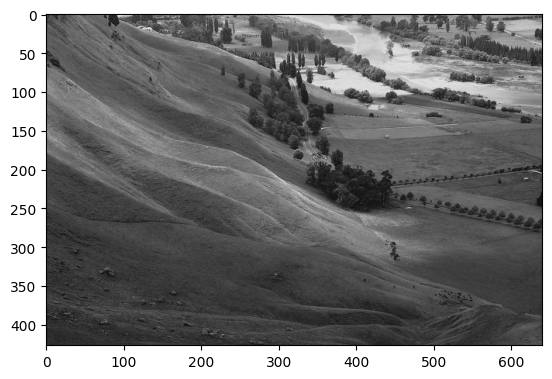

In [12]:
img2=cv2.imread("./test_assets/landscape.jpg",0)

plt.imshow(img2, cmap='gray')

In [13]:
h, w = img2.shape
P=2*h
Q=2*w

In [14]:
print(f"Original image size: {h} x {w}")
print(f"Padding parameters: P={P}, Q={Q}")

Original image size: 427 x 640
Padding parameters: P=854, Q=1280


In [15]:
# Step 2: Form padded image fp(x,y) of size PxQ
fp = np.zeros((P, Q), dtype=np.float32)
fp[:h, :w] = img2.astype(np.float32)

print(f"Padded image size: {fp.shape}")

Padded image size: (854, 1280)


In [16]:
# Step 3: Multiply fp(x,y) by (-1)^(x+y) to center its transform
centering_filter = np.zeros((P, Q), dtype=np.float32)
for y in range(P):
    for x in range(Q):
        centering_filter[y, x] = (-1) ** (x + y)

fp_centered = fp * centering_filter

In [17]:
# Step 4: Compute DFT F(u,v) of the image from step 3
F_uv = np.fft.fft2(fp_centered)

print(f"DFT size: {F_uv.shape}")

DFT size: (854, 1280)


In [18]:
# Step 5: Generate filter function H(u,v) and form product G(u,v) = H(u,v)F(u,v)
# Example: Low-pass filter (circular)
center_u, center_v = P // 2, Q // 2
u, v = np.meshgrid(np.arange(Q), np.arange(P))
D = np.sqrt((u - center_v)**2 + (v - center_u)**2)

# Create a low-pass filter (you can modify this for different filters)
D0 = 50  # Cutoff frequency
H_uv = np.where(D <= D0, 1.0, 0.0)  # Ideal low-pass filter

# Form the product G(u,v) = H(u,v) * F(u,v)
G_uv = H_uv * F_uv

In [19]:
# Step 6: Obtain processed image gp(x,y)
gp_complex = np.fft.ifft2(G_uv)
gp = np.real(gp_complex) * centering_filter

In [20]:
# Step 7: Extract the final MxN region from top-left quadrant
g_final = gp[:h, :w]

In [21]:
# Convert to uint8 for display
g_final = np.clip(g_final, 0, 255).astype(np.uint8)

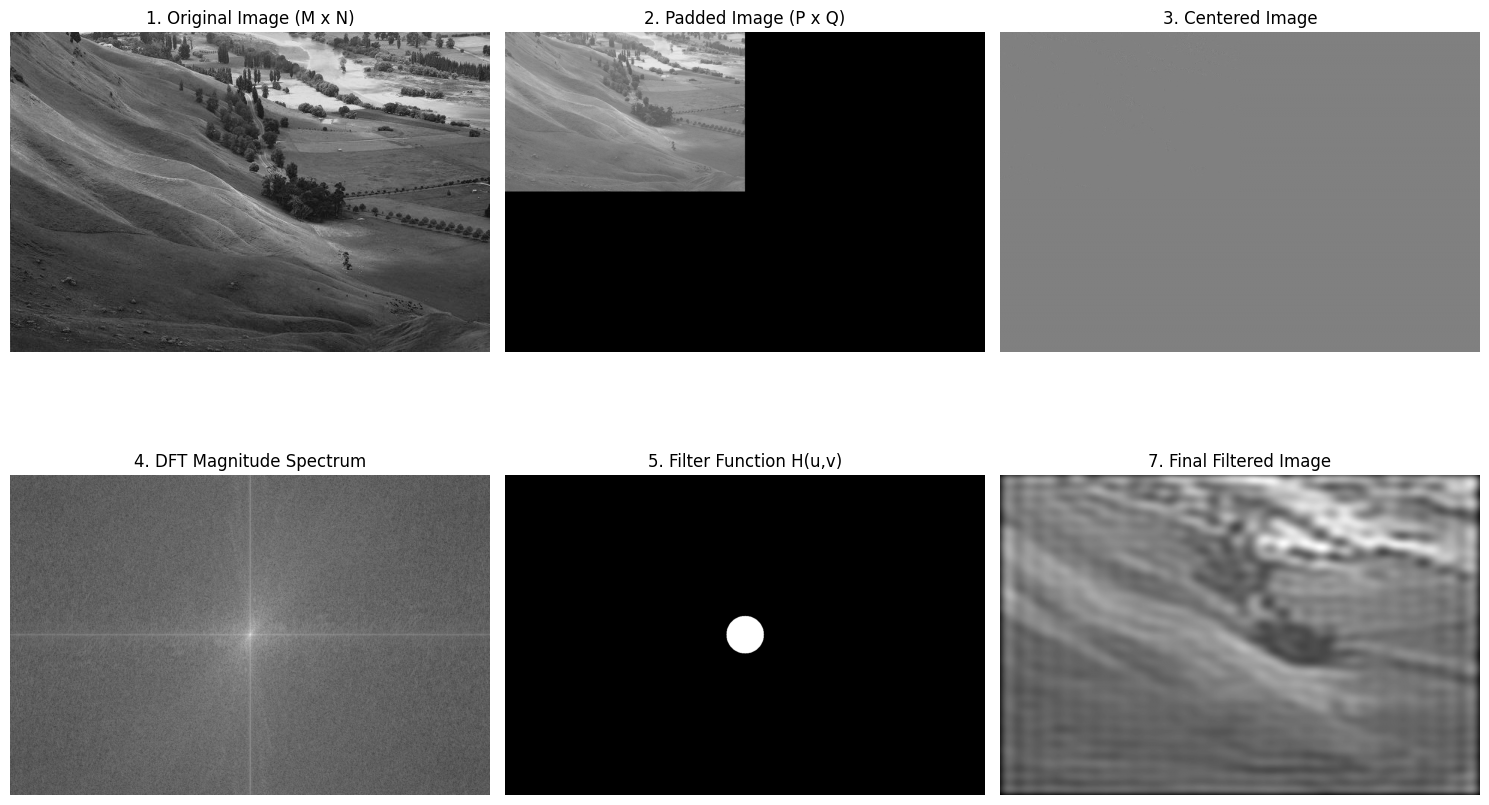

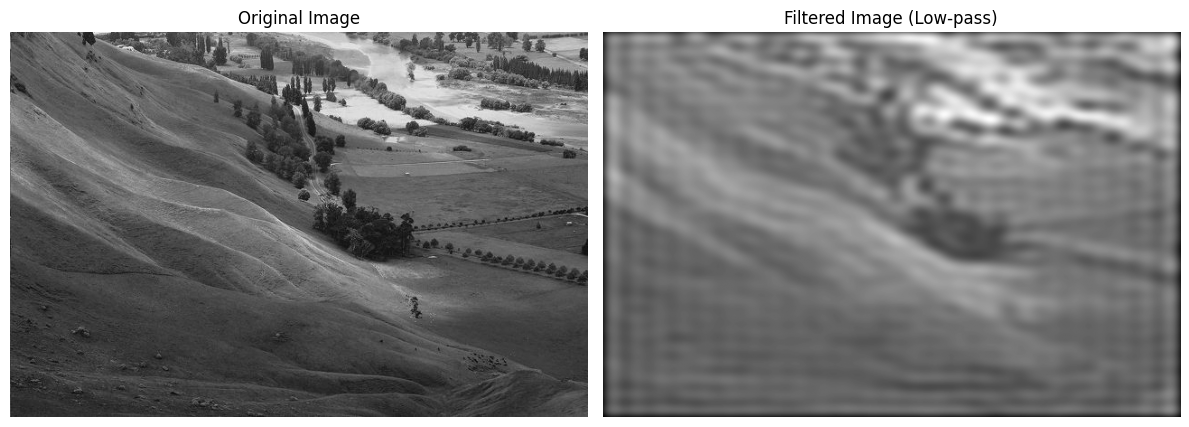

In [22]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original image
axes[0, 0].imshow(img2, cmap='gray')
axes[0, 0].set_title('1. Original Image (M x N)')
axes[0, 0].axis('off')

# Padded image
axes[0, 1].imshow(fp, cmap='gray')
axes[0, 1].set_title('2. Padded Image (P x Q)')
axes[0, 1].axis('off')

# Centered image
axes[0, 2].imshow(fp_centered, cmap='gray')
axes[0, 2].set_title('3. Centered Image')
axes[0, 2].axis('off')

# Magnitude spectrum of DFT
axes[1, 0].imshow(np.log(np.abs(F_uv) + 1), cmap='gray')
axes[1, 0].set_title('4. DFT Magnitude Spectrum')
axes[1, 0].axis('off')

# Filter function
axes[1, 1].imshow(H_uv, cmap='gray')
axes[1, 1].set_title('5. Filter Function H(u,v)')
axes[1, 1].axis('off')

# Final result
axes[1, 2].imshow(g_final, cmap='gray')
axes[1, 2].set_title('7. Final Filtered Image')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Compare original and filtered
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(g_final, cmap='gray')
axes[1].set_title('Filtered Image (Low-pass)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Lab Task

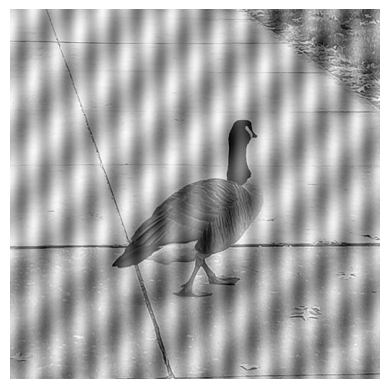

In [23]:
duck=cv2.imread("./test_assets/duck.png",0)

plt.imshow(duck, cmap="gray")
plt.axis("off")
plt.show()

In [24]:
# Forward transform
ft = np.fft.fft2(duck)
ft_shift = np.fft.fftshift(ft)

In [25]:
# Power spectrum
magnitude_spectrum_ac = np.abs(ft_shift)
magnitude_spectrum = 20 * np.log( magnitude_spectrum_ac + 1 ) # +1 to remove 0, 20 = scaling factor
magnitude_spectrum = cv2.normalize(magnitude_spectrum, None,0,255,cv2.NORM_MINMAX,dtype=cv2.CV_8U)

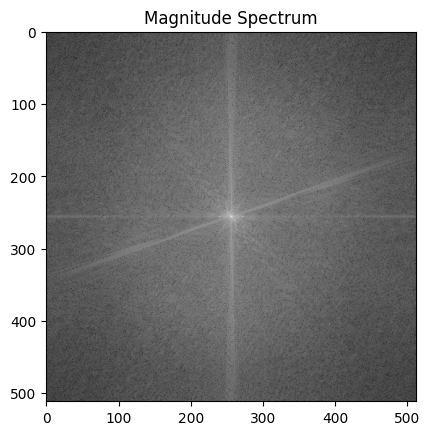

In [26]:
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum")
plt.show()

In [27]:
phase = np.angle(ft_shift)
phase_ = cv2.normalize(phase, None, 0, 255, cv2.NORM_MINMAX,dtype=cv2.CV_8U)

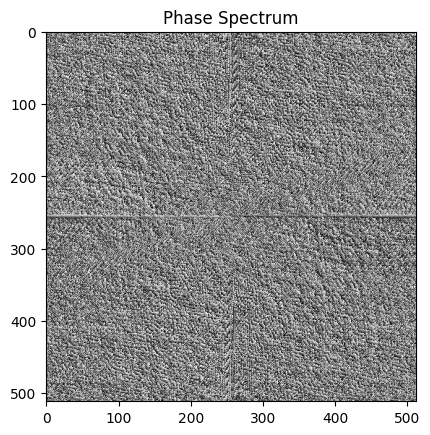

In [28]:
plt.imshow(phase_, cmap='gray')
plt.title("Phase Spectrum")
plt.show()

In [29]:
def notch_filter(img, notch_centers, radius, filter_type='reject'):
    """
    Create a notch filter to reject or pass specific frequencies
    
    Parameters:
    img: input image (2D array)
    notch_centers: list of tuples [(u1,v1), (u2,v2), ...] - notch center positions
    radius: radius of each notch
    filter_type: 'reject' (default) or 'pass'
    
    Returns:
    notch_mask: filter mask
    """
    h, w = img.shape
    
    # Create coordinate grids
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # Initialize filter as all ones (pass everything)
    notch_mask = np.ones((h, w), dtype=np.float32)
    
    # Center of frequency domain
    center_u, center_v = h // 2, w // 2
    
    for center in notch_centers:
        u_notch, v_notch = center
        
        # Create symmetric notch pairs
        # Positive notch at (u_notch, v_notch)
        D1 = np.sqrt((u - (center_v + u_notch - center_v))**2 + 
                     (v - (center_u + v_notch - center_u))**2)
        
        # Symmetric notch at (-u_notch, -v_notch)
        D2 = np.sqrt((u - (center_v - (u_notch - center_v)))**2 + 
                     (v - (center_u - (v_notch - center_u)))**2)
        
        if filter_type == 'reject':
            # Notch reject: set to 0 where distance <= radius
            notch_mask = notch_mask * (D1 > radius) * (D2 > radius)
        else:  # filter_type == 'pass'
            # Notch pass: set to 0 everywhere except where distance <= radius
            pass_mask = (D1 <= radius) | (D2 <= radius)
            notch_mask = notch_mask * pass_mask
    
    return notch_mask

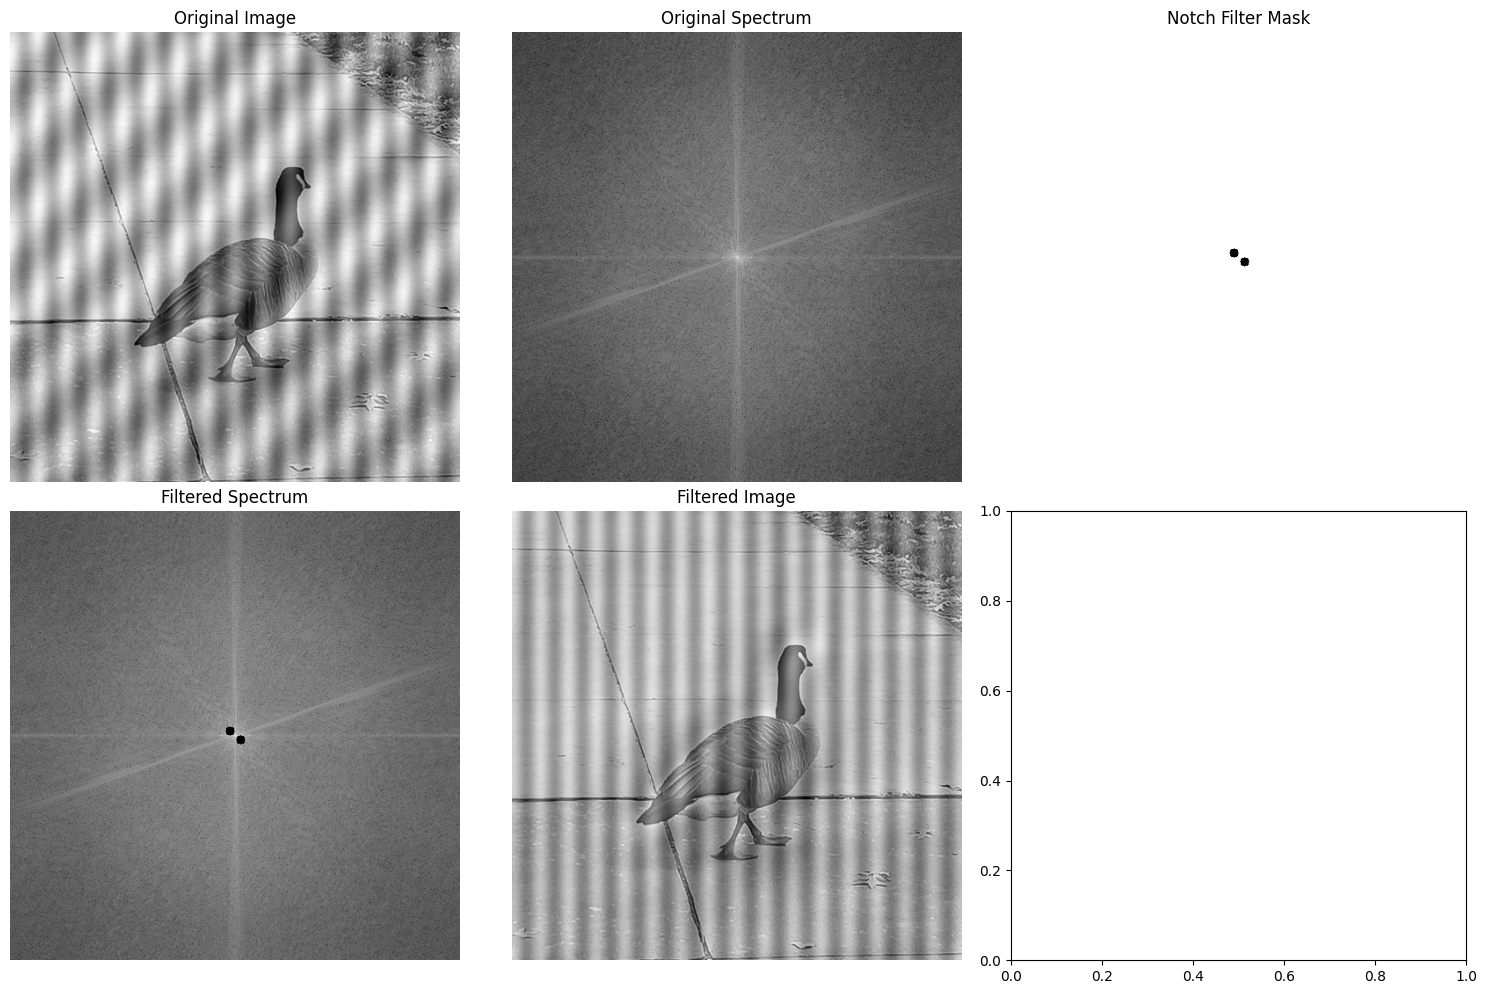

In [ ]:
# Example usage for your specific case:
def apply_notch_filter_to_duck():
    # Load duck image
    duck = cv2.imread("./test_assets/duck.png", 0)
    
    # Forward transform
    ft = np.fft.fft2(duck)
    ft_shift = np.fft.fftshift(ft)
    
    # Define notch centers and radius
    notch_centers = [(262, 261)]  # Your specific coordinates
    radius = 5
    
    # Create notch reject filter
    notch_mask = notch_filter(duck, notch_centers, radius, 'reject')
    
    # Apply filter
    ft_filtered = ft_shift * notch_mask
    
    # Inverse transform
    ft_ishift = np.fft.ifftshift(ft_filtered)
    img_filtered = np.fft.ifft2(ft_ishift)
    img_filtered = np.abs(img_filtered)
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(duck, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Original spectrum
    magnitude_original = 20 * np.log(np.abs(ft_shift) + 1)
    axes[0, 1].imshow(magnitude_original, cmap='gray')
    axes[0, 1].set_title('Original Spectrum')
    axes[0, 1].axis('off')
    
    # Notch filter mask
    axes[0, 2].imshow(notch_mask, cmap='gray')
    axes[0, 2].set_title('Notch Filter Mask')
    axes[0, 2].axis('off')
    
    # Filtered spectrum
    magnitude_filtered = 20 * np.log(np.abs(ft_filtered) + 1)
    axes[1, 0].imshow(magnitude_filtered, cmap='gray')
    axes[1, 0].set_title('Filtered Spectrum')
    axes[1, 0].axis('off')
    
    # Filtered image
    axes[1, 1].imshow(img_filtered, cmap='gray')
    axes[1, 1].set_title('Filtered Image')
    axes[1, 1].axis('off')
    
    # Difference
    axes[1, 2].imshow(np.abs(duck.astype(float) - img_filtered), cmap='gray')
    axes[1, 2].set_title('Difference')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img_filtered, notch_mask

# Run the example
filtered_duck, filter_mask = apply_notch_filter_to_duck()

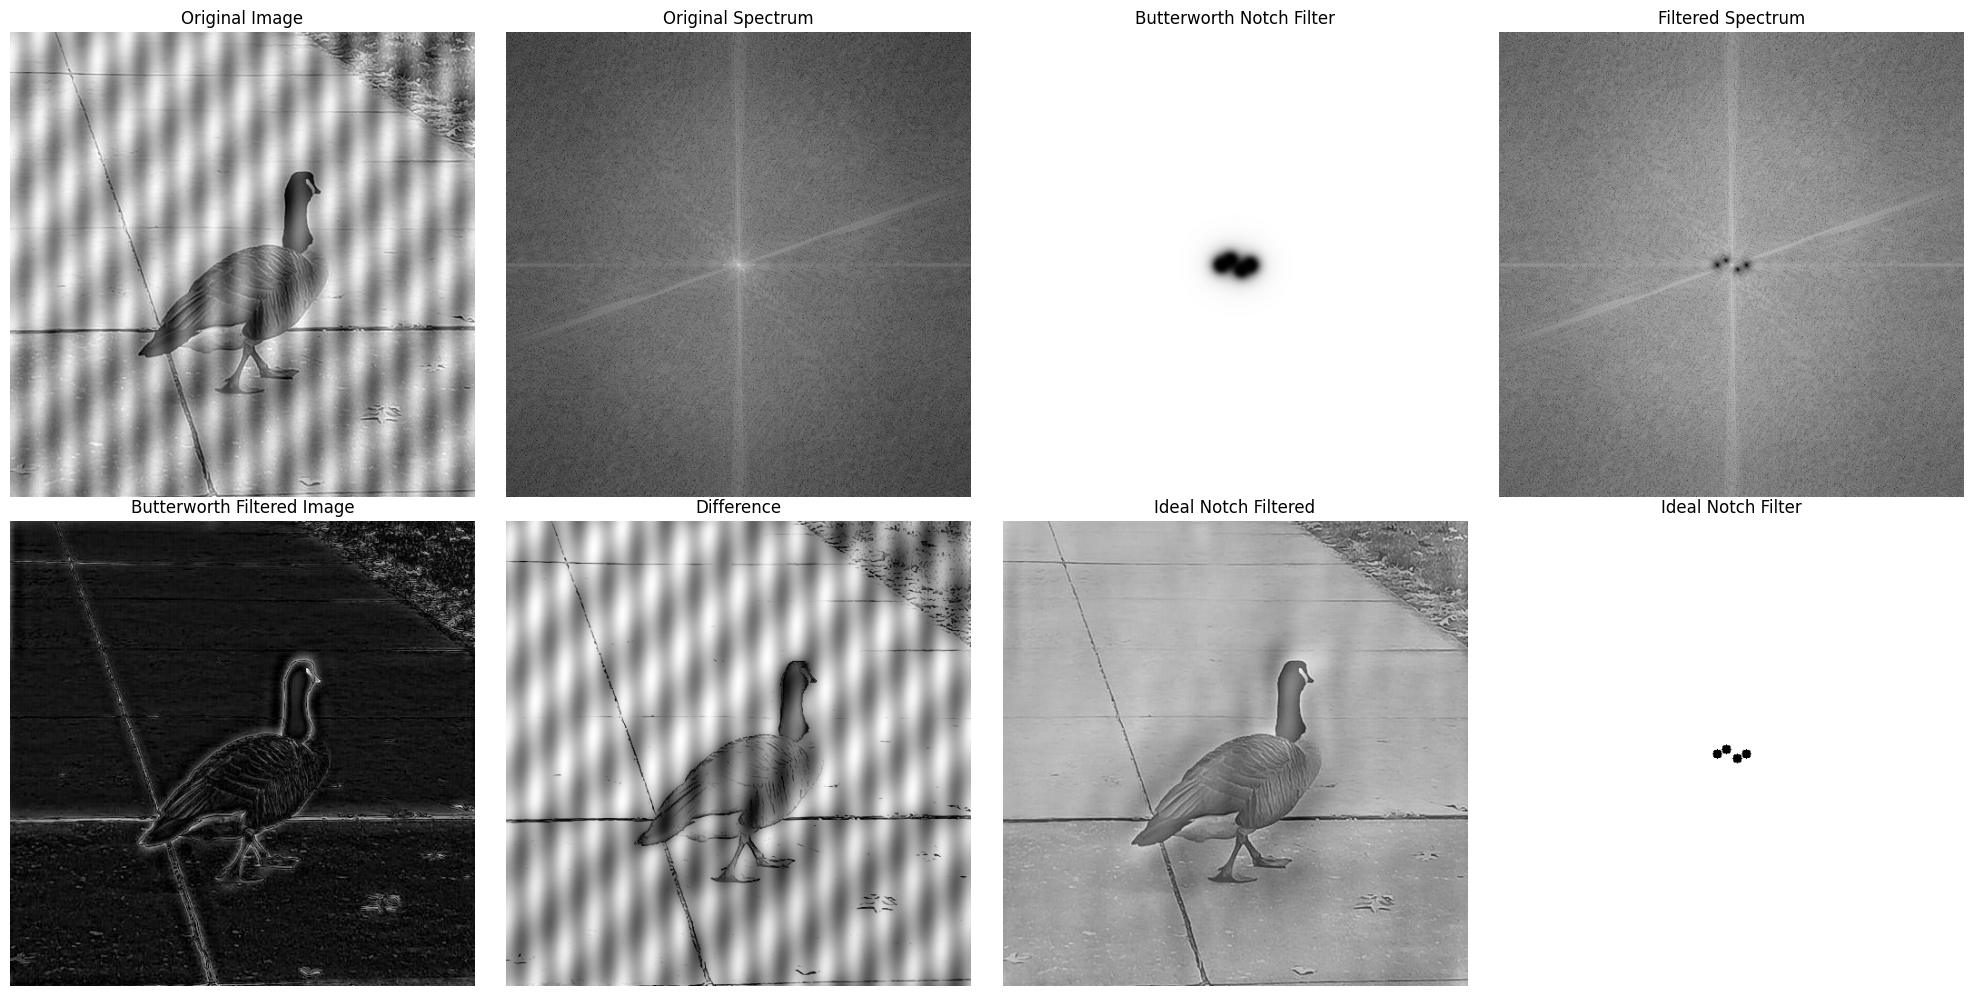

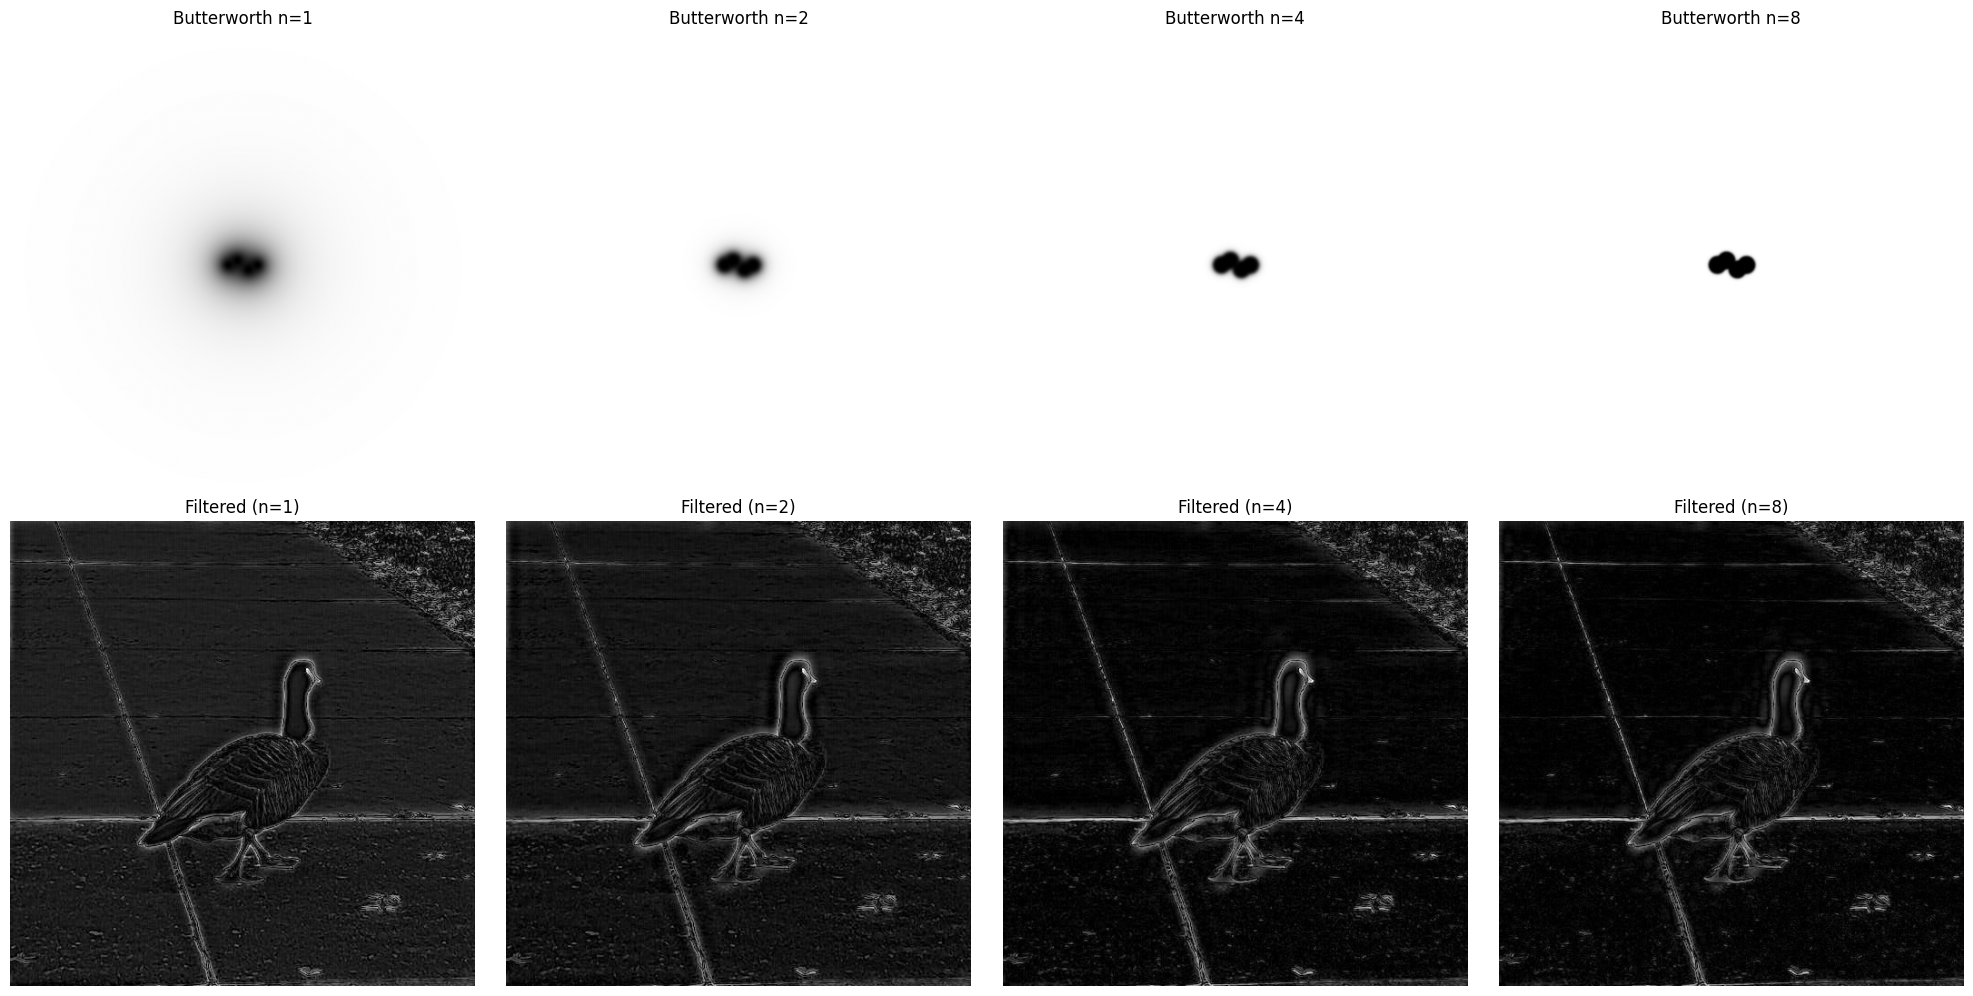

In [31]:
def butterworth_notch_filter(img, notch_centers, D0, n=2, filter_type='reject'):
    """
    Create a Butterworth notch filter to reject or pass specific frequencies
    
    Parameters:
    img: input image (2D array)
    notch_centers: list of tuples [(uk,vk), ...] - notch center positions
    D0: cutoff frequency (radius) for each notch
    n: order of the Butterworth filter (default=2)
    filter_type: 'reject' (default) or 'pass'
    
    Returns:
    notch_mask: Butterworth notch filter mask
    """
    h, w = img.shape
    
    # Create coordinate grids
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # Center of frequency domain
    center_u, center_v = h // 2, w // 2
    
    # Initialize filter as all ones
    H_NR = np.ones((h, w), dtype=np.float32)
    
    for center in notch_centers:
        uk, vk = center
        
        # Distance from positive notch center (uk, vk)
        Dk = np.sqrt((u - (center_v + uk - center_v))**2 + 
                     (v - (center_u + vk - center_u))**2)
        
        # Distance from negative notch center (-uk, -vk)
        D_k = np.sqrt((u - (center_v - (uk - center_v)))**2 + 
                      (v - (center_u - (vk - center_u)))**2)
        
        # Butterworth notch reject filter formula
        # H_NR(u,v) = [1/(1+(D0/Dk)^2n)] * [1/(1+(D0/D_k)^2n)]
        
        # Avoid division by zero
        Dk = np.where(Dk == 0, 1e-10, Dk)
        D_k = np.where(D_k == 0, 1e-10, D_k)
        
        if filter_type == 'reject':
            # Butterworth notch reject
            H1 = 1 / (1 + (D0 / Dk)**(2*n))
            H2 = 1 / (1 + (D0 / D_k)**(2*n))
            H_NR = H_NR * H1 * H2
        else:  # filter_type == 'pass'
            # Butterworth notch pass (complement of reject)
            H1 = 1 / (1 + (Dk / D0)**(2*n))
            H2 = 1 / (1 + (D_k / D0)**(2*n))
            H_NR = H_NR * H1 * H2
    
    return H_NR

def apply_butterworth_notch_filter():
    """Apply Butterworth notch filter to duck image"""
    # Load duck image
    duck = cv2.imread("./test_assets/duck.png", 0)
    
    # Forward transform
    ft = np.fft.fft2(duck)
    ft_shift = np.fft.fftshift(ft)
    
    # Define notch centers and parameters
    notch_centers = [(272, 256), (262, 261)]  # Your specific coordinates
    D0 = 10  # Cutoff frequency
    n = 2    # Butterworth order
    
    # Create Butterworth notch reject filter
    butterworth_mask = butterworth_notch_filter(duck, notch_centers, D0, n, 'reject')
    
    # Apply filter
    ft_filtered = ft_shift * butterworth_mask
    
    # Inverse transform
    ft_ishift = np.fft.ifftshift(ft_filtered)
    img_filtered = np.fft.ifft2(ft_ishift)
    img_filtered = np.abs(img_filtered)
    
    # Visualization
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Original image
    axes[0, 0].imshow(duck, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Original spectrum
    magnitude_original = 20 * np.log(np.abs(ft_shift) + 1)
    axes[0, 1].imshow(magnitude_original, cmap='gray')
    axes[0, 1].set_title('Original Spectrum')
    axes[0, 1].axis('off')
    
    # Butterworth notch filter mask
    axes[0, 2].imshow(butterworth_mask, cmap='gray')
    axes[0, 2].set_title('Butterworth Notch Filter')
    axes[0, 2].axis('off')
    
    # Filtered spectrum
    magnitude_filtered = 20 * np.log(np.abs(ft_filtered) + 1)
    axes[0, 3].imshow(magnitude_filtered, cmap='gray')
    axes[0, 3].set_title('Filtered Spectrum')
    axes[0, 3].axis('off')
    
    # Filtered image
    axes[1, 0].imshow(img_filtered, cmap='gray')
    axes[1, 0].set_title('Butterworth Filtered Image')
    axes[1, 0].axis('off')
    
    # Difference
    axes[1, 1].imshow(np.abs(duck.astype(float) - img_filtered), cmap='gray')
    axes[1, 1].set_title('Difference')
    axes[1, 1].axis('off')
    
    # Compare with ideal notch filter
    ideal_mask = notch_filter(duck, notch_centers, 5, 'reject')
    ft_ideal = ft_shift * ideal_mask
    ft_ideal_ishift = np.fft.ifftshift(ft_ideal)
    img_ideal = np.abs(np.fft.ifft2(ft_ideal_ishift))
    
    axes[1, 2].imshow(img_ideal, cmap='gray')
    axes[1, 2].set_title('Ideal Notch Filtered')
    axes[1, 2].axis('off')
    
    # Filter comparison
    axes[1, 3].imshow(ideal_mask, cmap='gray')
    axes[1, 3].set_title('Ideal Notch Filter')
    axes[1, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img_filtered, butterworth_mask

# Test different Butterworth orders
def compare_butterworth_orders():
    """Compare different orders of Butterworth notch filter"""
    duck = cv2.imread("./test_assets/duck.png", 0)
    ft = np.fft.fft2(duck)
    ft_shift = np.fft.fftshift(ft)
    
    notch_centers = [(272, 256), (262, 261)]
    D0 = 10
    orders = [1, 2, 4, 8]
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for i, n in enumerate(orders):
        # Create filter
        mask = butterworth_notch_filter(duck, notch_centers, D0, n, 'reject')
        
        # Apply filter
        ft_filtered = ft_shift * mask
        ft_ishift = np.fft.ifftshift(ft_filtered)
        img_filtered = np.abs(np.fft.ifft2(ft_ishift))
        
        # Display filter
        axes[0, i].imshow(mask, cmap='gray')
        axes[0, i].set_title(f'Butterworth n={n}')
        axes[0, i].axis('off')
        
        # Display filtered image
        axes[1, i].imshow(img_filtered, cmap='gray')
        axes[1, i].set_title(f'Filtered (n={n})')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the examples
filtered_duck_butterworth, butterworth_filter_mask = apply_butterworth_notch_filter()
compare_butterworth_orders()